# Session 01: Introduction to Computer Vision

**CVI4IC - Summer Semester 2026**

In this notebook, we'll set up our environment and get a first taste of working with images using OpenCV and Python.

## 1. Environment Setup

First, let's install and import the required packages.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")

OpenCV version: 4.13.0
NumPy version: 2.4.2


## 2. Datasets

Throughout this course we use two main datasets:

1. **Fruits-360** — 174,700 images of 251 fruit/vegetable classes (100×100 px). Used for exercises in sessions 01–12.
2. **BAMBI** — Aerial wildlife monitoring imagery for the student project. Contains drone flights with annotations for roe deer, red deer, wild boar, and more.

### 2.1 Fruits-360

The [Fruits-360](https://github.com/fruits-360/) dataset contains 174,700 images of 251 classes (fruits, vegetables, nuts, seeds), all 100×100 px. It is organized into `Training/` and `Test/` splits by class name.

In [4]:
!git clone --depth 1 https://github.com/fruits-360/fruits-360-100x100.git 2>./fruits || echo "Dataset already cloned."


In [2]:
# Set dataset root
DATASET_ROOT = Path("fruits-360-100x100")
TRAIN_DIR = DATASET_ROOT / "Training"
TEST_DIR = DATASET_ROOT / "Test"

# List available classes
classes = sorted(os.listdir(TRAIN_DIR))
print(f"\nFruits-360: {len(classes)} classes found")
print(f"First 10 classes: {classes[:10]}")


Fruits-360: 251 classes found
First 10 classes: ['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20']


### 2.2 BAMBI — Aerial Wildlife Monitoring (Project Dataset)

The [BAMBI](https://github.com/bambi-eco/Dataset) dataset contains drone imagery for wildlife monitoring. You will use this dataset for your **course project**.

**Download steps:**
1. Clone the dataset repository (contains metadata and download scripts)
2. Filter flights by species of interest (e.g., roe deer, red deer, wild boar)
3. Download the selected flights from Zenodo using the provided script
4. Extract the downloaded zip files
5. Extract thermal frames from the downloaded flight videos

> The `-f` flag specifies which flight IDs to download. Adjust the species filter and flight IDs to match your project needs.

In [ ]:
# Step 1: Clone the BAMBI dataset repository
!git clone https://github.com/bambi-eco/Dataset.git 2>/dev/null || echo "BAMBI repo already cloned."

# Step 2: Filter flights by species of interest
!python Dataset/filter_flights.py --folder Dataset/flight_metadata/ --species "Roe deer" "Red deer" "Wild boar"

# Step 3: Download selected flights from Zenodo
# -f specifies flight IDs to download (e.g., 0 1 2)
!python Dataset/download_from_zenodo.py \
    -s Dataset/flight_metadata/zenodo_upload_summary.json \
    -f 0 1

# Step 4: Extract the downloaded zip files
import glob
for zf in sorted(glob.glob("bambi_downloads/**/*.zip", recursive=True)):
    print(f"Extracting {zf} ...")
    zf = "C:\\Users\\jojog\\Documents\\School\\Semester_4\\CIV4\\cvi4\\" + zf
    !unzip -q -o "{zf}" -d bambi_downloads/

# Step 5: Extract thermal frames from downloaded flight videos
# --no-rgb skips RGB frames and only extracts thermal images
!python Dataset/frame_extraction.py bambi_downloads exported_frames --no-rgb

"BAMBI repo already cloned."


The system cannot find the path specified.
C:\Users\jojog\AppData\Roaming\uv\python\cpython-3.11.7-windows-x86_64-none\python.exe: can't open file 'c:\\Users\\jojog\\Documents\\School\\Semester_4\\CIV4\\cvi4\\Dataset\\filter_flights.py': [Errno 2] No such file or directory
C:\Users\jojog\AppData\Roaming\uv\python\cpython-3.11.7-windows-x86_64-none\python.exe: can't open file 'c:\\Users\\jojog\\Documents\\School\\Semester_4\\CIV4\\cvi4\\Dataset\\download_from_zenodo.py': [Errno 2] No such file or directory
C:\Users\jojog\AppData\Roaming\uv\python\cpython-3.11.7-windows-x86_64-none\python.exe: can't open file 'c:\\Users\\jojog\\Documents\\School\\Semester_4\\CIV4\\cvi4\\Dataset\\frame_extraction.py': [Errno 2] No such file or directory


In [30]:
!python Dataset/frame_extraction.py bambi_downloads/flight_0/ exported_frames --no-rgb

Found 1 video(s):

  [0] 0_matched_processed.mp4  <->  0_gt.txt

  Video: 0_matched_processed.mp4
  ID: 0  MOT: 0_gt.txt
  Resolution: 2048x1024 (each half: 1024x1024)
  Total frames: 9840, FPS: 29.97
  Frame range: 0 to end (exclusive)
  Sample rate: every 1 frame(s)
  Naming: 0_<frame_idx>.png
    Exported 100 frames (frame index 99)...
    Exported 200 frames (frame index 199)...
    Exported 300 frames (frame index 299)...
    Exported 400 frames (frame index 399)...
    Exported 500 frames (frame index 499)...
    Exported 600 frames (frame index 599)...
    Exported 700 frames (frame index 699)...
    Exported 800 frames (frame index 799)...
    Exported 900 frames (frame index 899)...
    Exported 1000 frames (frame index 999)...
    Exported 1100 frames (frame index 1099)...
    Exported 1200 frames (frame index 1199)...
    Exported 1300 frames (frame index 1299)...
    Exported 1400 frames (frame index 1399)...
    Exported 1500 frames (frame index 1499)...
    Exported 1600 

### 2.3 BAMBI — ALFS Data

The ALFS (Airborne Light Field Sampling) subset of BAMBI contains pre-rendered **thermal** detection images from nadir UAV recordings of forest wildlife. This is a single ~5 GB download — no flight filtering needed.

Zenodo DOI: [10.5281/zenodo.18772136](https://doi.org/10.5281/zenodo.18772136)

> **Important:** Frames from a single flight are very similar. When creating train/test splits, split by **flight** (not by frame) to avoid data leakage!

In [ ]:
# Download ALFS dataset from Zenodo (~5 GB)
!wget -q --show-progress https://zenodo.org/api/records/18772136/files/dataset.zip/content -O alfs_dataset.zip
!unzip -q alfs_dataset.zip -d alfs_data/

## 3. Loading and Displaying Images

Let's load some fruit images from the dataset and explore their properties.

In [3]:
# Load a fruit image
apple_dir = TRAIN_DIR / "Apple Red 1"
img_path = sorted(apple_dir.glob("*.jpg"))[0]
img = cv2.imread(str(img_path))

print(f"Image path: {img_path.name}")
print(f"Image shape: {img.shape}  (height, width, channels)")
print(f"Image dtype: {img.dtype}")
print(f"Pixel value range: [{img.min()}, {img.max()}]")

Image path: 0_100.jpg
Image shape: (100, 100, 3)  (height, width, channels)
Image dtype: uint8
Pixel value range: [7, 255]


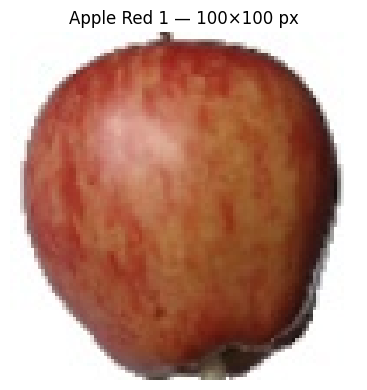

In [4]:
# Display with matplotlib (OpenCV loads as BGR — convert to RGB)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(4, 4))
plt.imshow(img_rgb)
plt.title(f"Apple Red 1 — {img.shape[1]}×{img.shape[0]} px")
plt.axis("off")
plt.tight_layout()
plt.show()

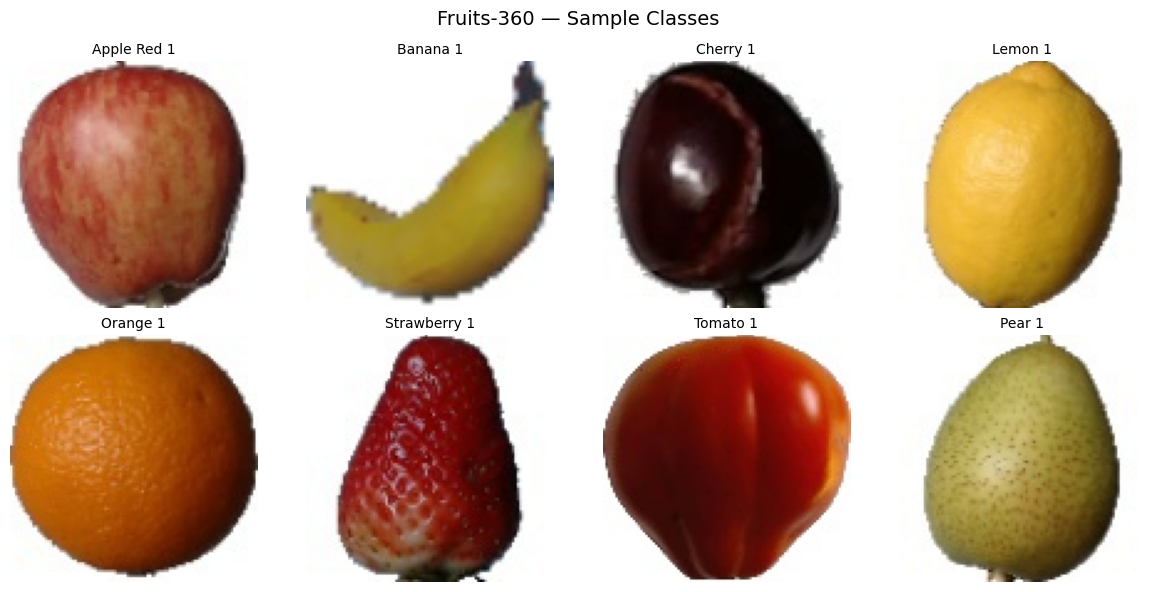

In [5]:
# Display a grid of different fruit classes
sample_classes = ["Apple Red 1", "Banana 1", "Cherry 1", "Lemon 1", "Orange 1", "Strawberry 1", "Tomato 1", "Pear 1"]
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for ax, cls_name in zip(axes.flat, sample_classes):
    cls_dir = TRAIN_DIR / cls_name
    img_path = sorted(cls_dir.glob("*.jpg"))[0]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(cls_name, fontsize=10)
    ax.axis("off")

plt.suptitle("Fruits-360 — Sample Classes", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Basic Image Operations

Pixel at (50, 50): B=96, G=168, R=186
Cropped region shape: (60, 60, 3)
Resized shape: (256, 256, 3)


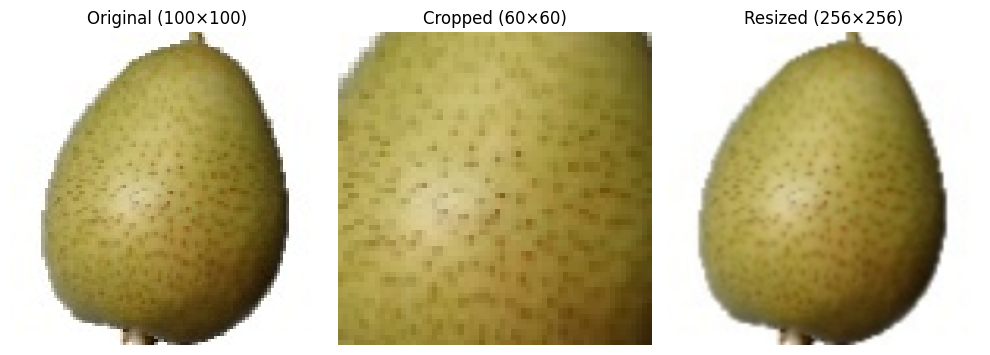

In [6]:
# Access individual pixel values (center of the 100x100 image)
pixel = img[50, 50]
print(f"Pixel at (50, 50): B={pixel[0]}, G={pixel[1]}, R={pixel[2]}")

# Crop a region (the fruit is centered in the image)
crop = img[20:80, 20:80]
print(f"Cropped region shape: {crop.shape}")

# Resize to a larger image
resized = cv2.resize(img, (256, 256))
print(f"Resized shape: {resized.shape}")

# Show original, cropped, and resized side by side
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Original ({img.shape[1]}×{img.shape[0]})")
axes[1].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Cropped ({crop.shape[1]}×{crop.shape[0]})")
axes[2].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[2].set_title(f"Resized ({resized.shape[1]}×{resized.shape[0]})")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. Drawing on Images

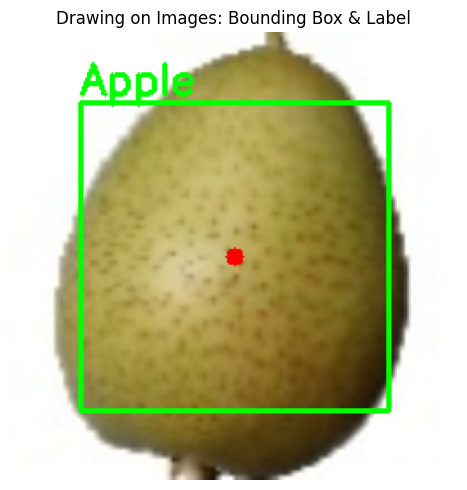

In [7]:
# Draw bounding boxes and labels on a fruit image
img_draw = cv2.resize(img.copy(), (256, 256))

# Simulate a detection bounding box around the fruit
cv2.rectangle(img_draw, (40, 40), (216, 216), (0, 255, 0), 2)
cv2.putText(img_draw, "Apple", (40, 35), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

# Draw a circle at the center
cv2.circle(img_draw, (128, 128), 5, (0, 0, 255), -1)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(img_draw, cv2.COLOR_BGR2RGB))
plt.title("Drawing on Images: Bounding Box & Label")
plt.axis("off")
plt.tight_layout()
plt.show()

## Exercises

1. **Explore the dataset:** Pick 3 fruit classes of your choice, load one image from each, and display them side by side. Print the number of images per class.
2. **Grid overlay:** Write a function `draw_grid(img, step=10)` that draws a grid overlay on any image. Test it on a fruit image.
3. **Resize comparison:** Load a fruit image and resize it to 32×32 using `cv2.INTER_NEAREST`, `cv2.INTER_LINEAR`, and `cv2.INTER_CUBIC`. Display all three results scaled back up to 256×256 — can you see the difference?

In [12]:
cls_dir

WindowsPath('fruits-360-100x100/Training/Cherry 1')

In [21]:
def count_files_in_matching_dirs(root_path, substring):
    root = Path(root_path)
    total_files = 0
    
    # Iterate through all directories (recursive)
    for path in root.rglob('*'):
        if path.is_dir() and substring in path.name:
            # Count only items that are files inside this specific directory
            # Use path.iterdir() to avoid double-counting sub-sub-directories
            file_count = sum(1 for item in path.iterdir())
            total_files += file_count
            print(f"Directory: {path.name} | Files: {file_count}")

    return total_files

Directory: Apple Red 1 | Files: 492
Directory: Apple Red 2 | Files: 492
Directory: Apple Red 3 | Files: 429
Directory: Apple Red Delicious 1 | Files: 490
Directory: Apple Red Yellow 1 | Files: 492
Directory: Apple Red Yellow 2 | Files: 672
Directory: Banana 1 | Files: 490
Directory: Banana 3 | Files: 233
Directory: Banana 4 | Files: 254
Directory: Banana Lady Finger 1 | Files: 450
Directory: Banana Red 1 | Files: 490
Directory: Cherry 1 | Files: 492
Directory: Cherry 2 | Files: 738
Directory: Cherry 3 | Files: 699
Directory: Cherry 4 | Files: 699
Directory: Cherry 5 | Files: 693
Directory: Cherry Rainier 1 | Files: 738
Directory: Cherry Rainier 2 | Files: 696
Directory: Cherry Rainier 3 | Files: 686
Directory: Cherry Sour 1 | Files: 456
Directory: Cherry Wax 1 | Files: 675
Directory: Cherry Wax 2 | Files: 228
Directory: Cherry Wax Black 1 | Files: 492
Directory: Cherry Wax Red 1 | Files: 492
Directory: Cherry Wax Red 2 | Files: 452
Directory: Cherry Wax Red 3 | Files: 454
Directory: Ch

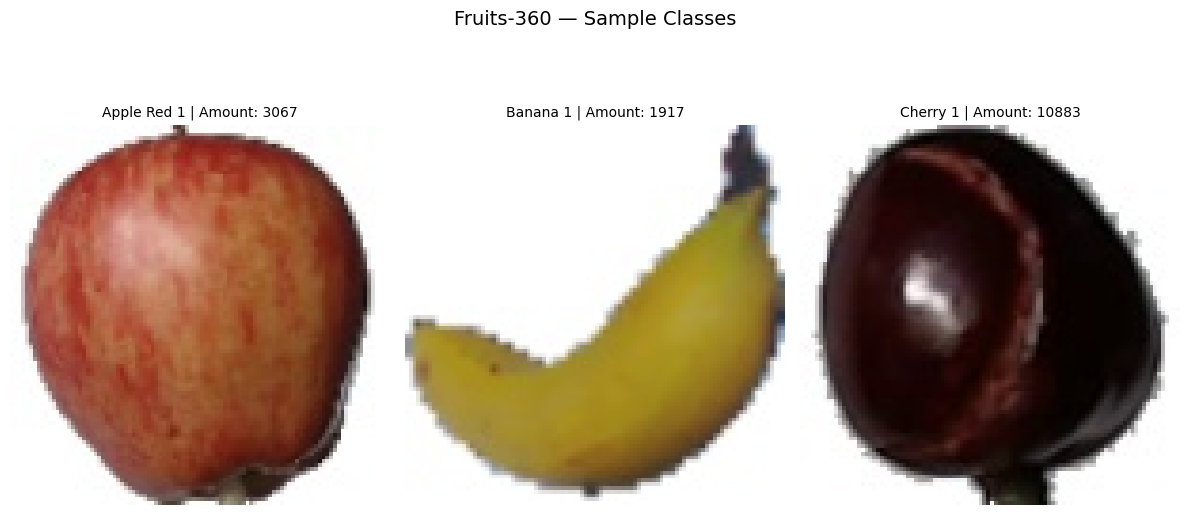

In [23]:
# Your code here
sample_classes = ["Apple Red 1", "Banana 1", "Cherry 1"]
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

for ax, cls_name in zip(axes.flat, sample_classes):
    cls_dir = TRAIN_DIR / cls_name
    img_path = sorted(cls_dir.glob("*.jpg"))[0]
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    split = cls_name.split()
    split.pop()
    substring = " ".join(split)
    
    ax.imshow(img_rgb)
    ax.set_title(cls_name+f" | Amount: {count_files_in_matching_dirs(TRAIN_DIR, substring)}", fontsize=10)
    ax.axis("off")

plt.suptitle("Fruits-360 — Sample Classes", fontsize=14)
plt.tight_layout()
plt.show()

In [32]:
cls_name = "Apple Red 1"
cls_dir = TRAIN_DIR / cls_name
img_path = sorted(cls_dir.glob("*.jpg"))[0]
img = cv2.imread(str(img_path))
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

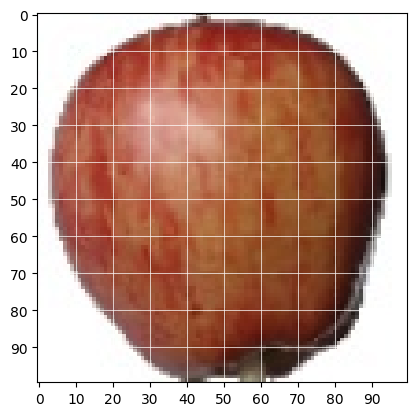

In [45]:
from matplotlib import ticker
from numpy import ndarray
def draw_grid(img: ndarray, step: int=10, ax=None):
    # plt.imshow(img_rgb)
    # plt.xticks(ticker.MultipleLocator(10))
    # plt.yticks(ticker.MultipleLocator(10))
    # plt.grid(True)
    if ax is None:
        fig, ax = plt.subplots()
    ax.imshow(img)

    # Force grid every 10 pixels
    ax.xaxis.set_major_locator(ticker.MultipleLocator(step))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(step))

    # Ensure grid is visible over the image
    ax.grid(True, color='white', linewidth=0.5, zorder=10)

draw_grid(img_rgb)

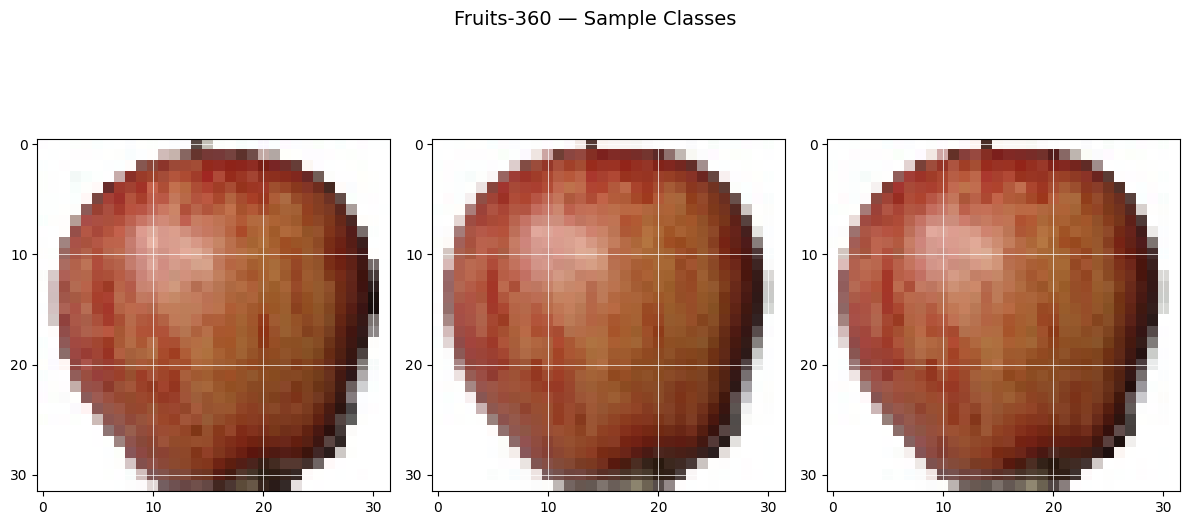

In [51]:
resize_methods = [cv2.INTER_NEAREST, cv2.INTER_LINEAR, cv2.INTER_CUBIC]
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
size = (32, 32)
smalls = []

for ax, interpolation in zip(axes.flat, resize_methods):
    small = cv2.resize(img_rgb, size, interpolation=interpolation)
    smalls.append(small)
    draw_grid(small, 10, ax)

plt.suptitle("Fruits-360 — Sample Classes", fontsize=14)
plt.tight_layout()
plt.show()

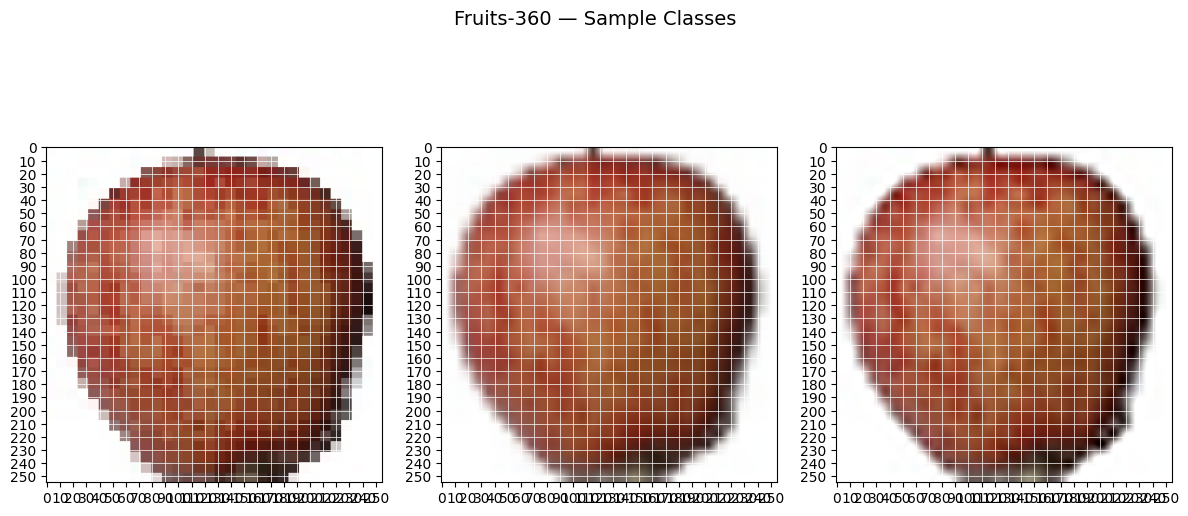

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(12, 6))
size = (255, 255)

for ax, small, interpolation in zip(axes.flat, smalls, resize_methods):
    big = cv2.resize(small, size, interpolation=interpolation)
    draw_grid(big, 10, ax)

plt.suptitle("Fruits-360 — Sample Classes", fontsize=14)
plt.tight_layout()
plt.show()